<a href="https://colab.research.google.com/github/RusieckiFilip/Inzynieria_Obliczeniowa_UW/blob/main/NLP_OBL_INZ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 21.6 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2024.10.0
    Uninstalling fsspec-2024.10.0:
      Successfully uninstalled fsspec-2024.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2024.10.0 requires fsspec==2024.10.0, but you have fsspec 2024.9.0 which is incompatible.


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.2/20.2 MB 56.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pl_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


/usr/local/lib/python3.11/dist-packages/spacy/util.py:1740: UserWarning: [W111] Jupyter notebook detected: if using `prefer_gpu()` or `require_gpu()`, include it in the same cell right before `spacy.load()` to ensure that the model is loaded on the correct device. More information: http://spacy.io/usage/v3#jupyter-notebook-gpu
  warnings.warn(Warnings.W111)



=== Class Distribution ===
label
1    5127
0    4129
Name: count, dtype: int64


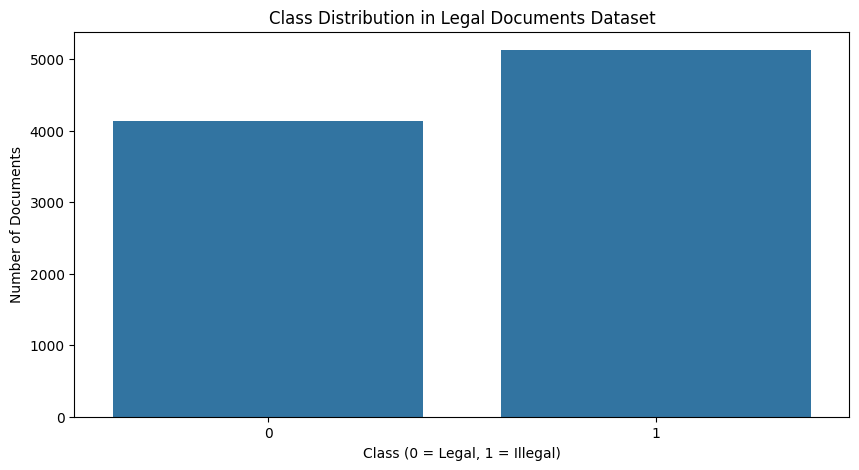


=== Text Length Analysis ===


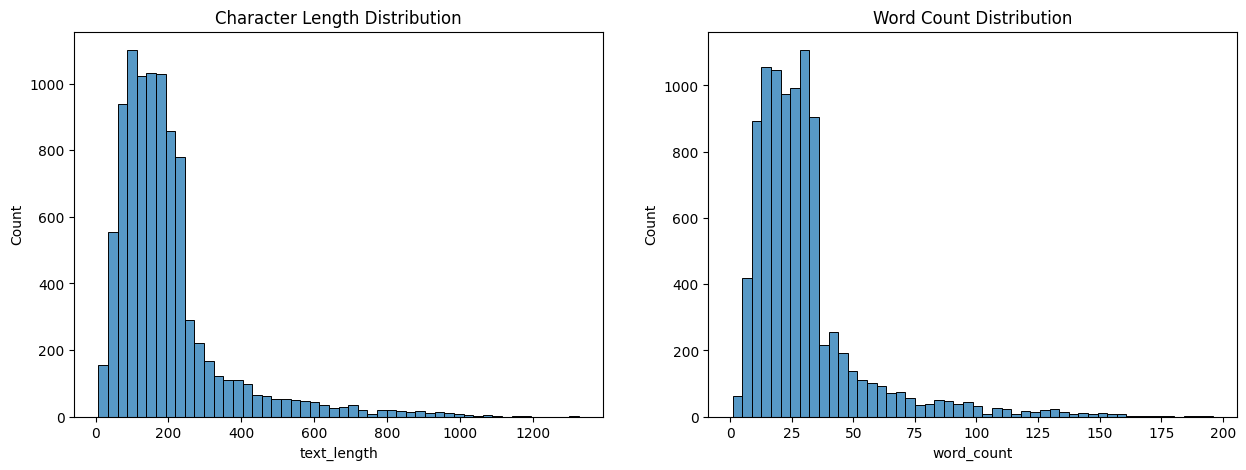


=== Word Frequency ===


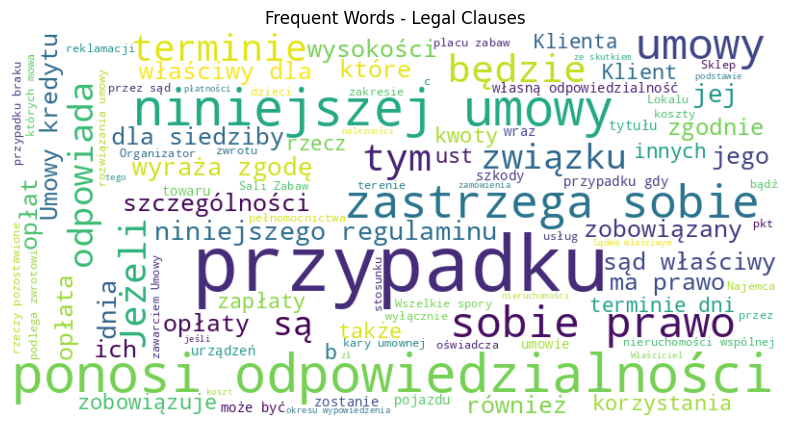

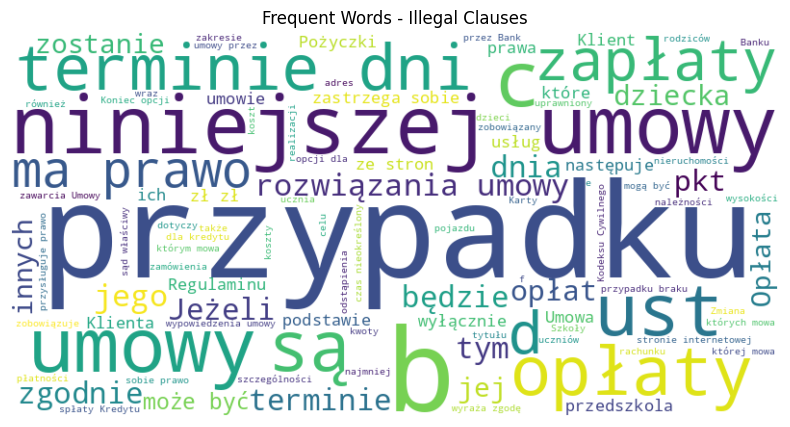


=== N-gram Analysis ===


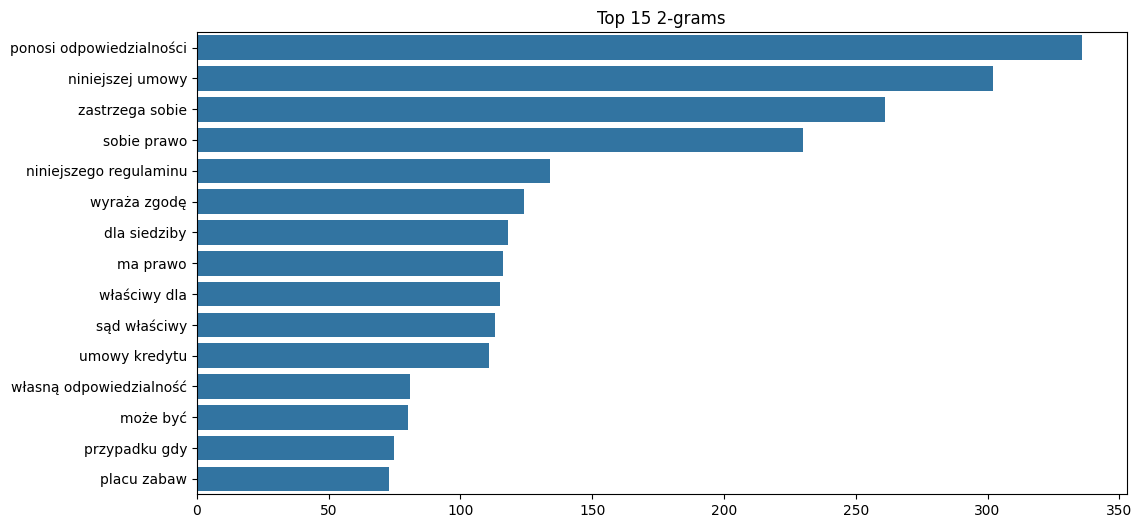

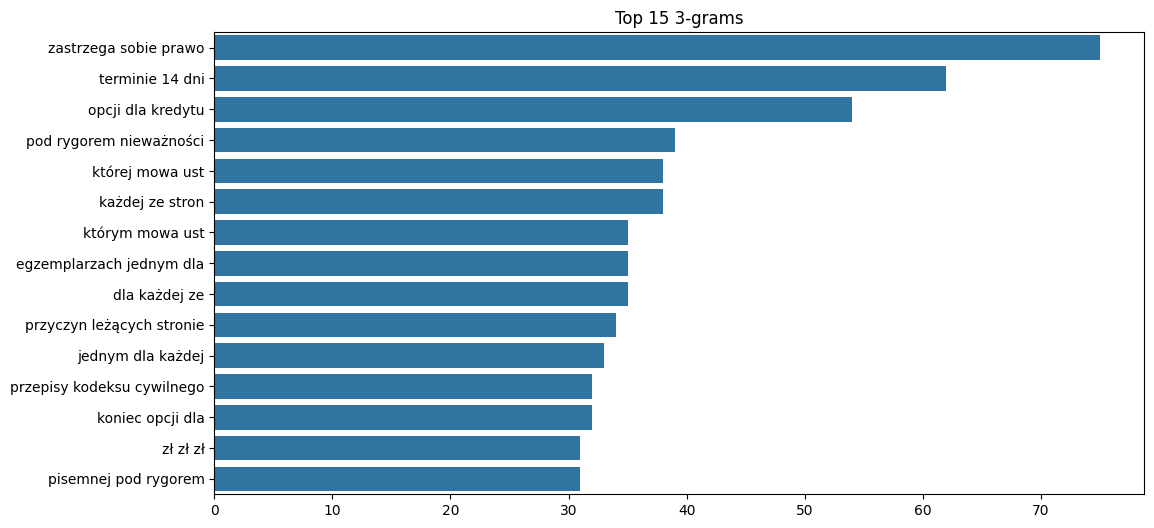


=== TF-IDF Analysis ===


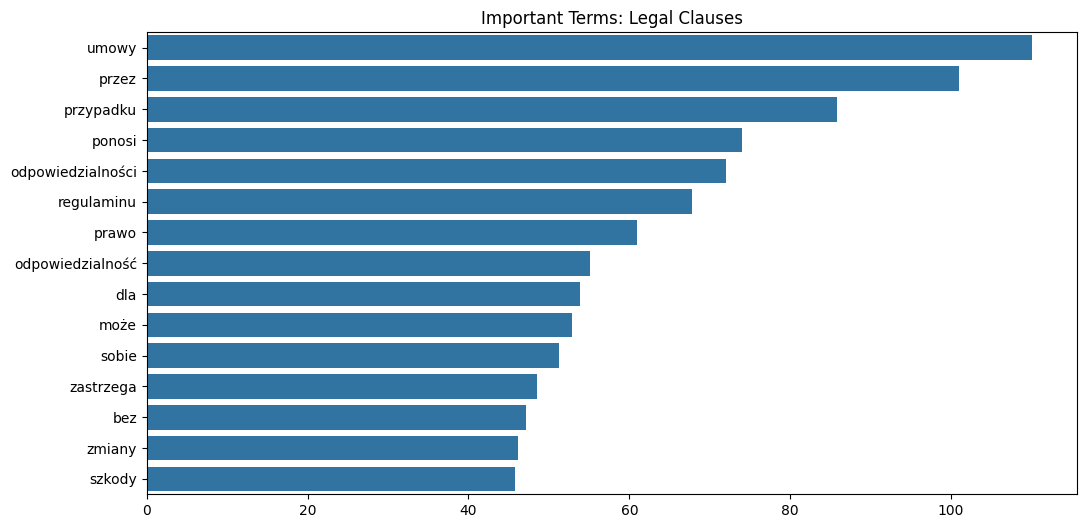

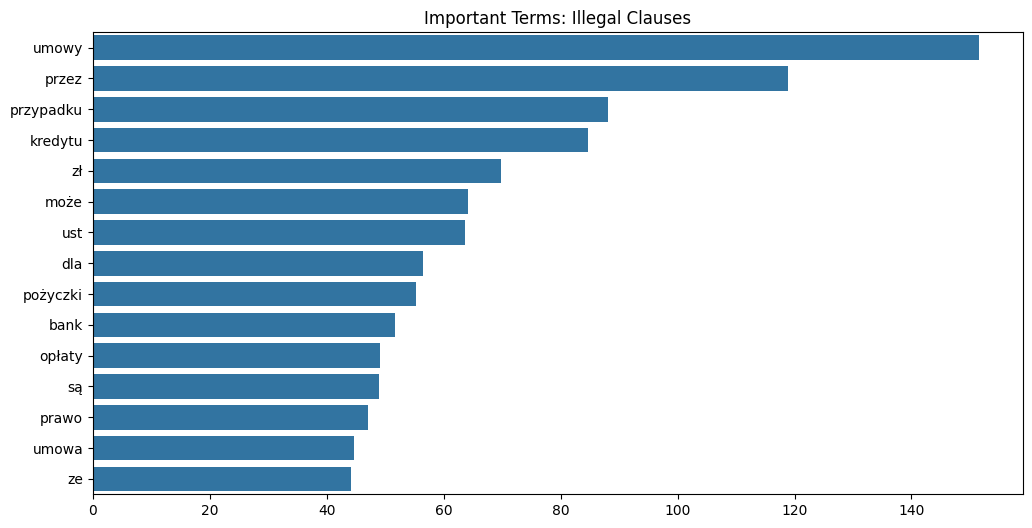

'\n# 6. Entity Analysis\ndef analyze_entities(text):\n    doc = nlp(text)\n    return [ent.text for ent in doc.ents if ent.label_ in ["DATE", "ORG", "LAW"]]\n\nprint("\n=== Entity Analysis Example ===")\nsample_text = df.iloc[0]["text"]\nprint("Entities found in sample text:", analyze_entities(sample_text))\n'

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
import seaborn as sns
import spacy

# Load dataset
dataset = load_dataset("laugustyniak/abusive-clauses-pl")

# Load Polish NLP model
!pip install spacy
!python -m spacy download pl_core_news_sm
nlp = spacy.load("pl_core_news_sm")

# Convert to pandas DataFrame
def dataset_to_df(dataset_dict):
    return pd.DataFrame({
        "text": dataset_dict["train"]["text"] + dataset_dict["validation"]["text"] + dataset_dict["test"]["text"],
        "label": dataset_dict["train"]["label"] + dataset_dict["validation"]["label"] + dataset_dict["test"]["label"]
    })

df = dataset_to_df(dataset)

# 1. Class Distribution Analysis
print("\n=== Class Distribution ===")
class_dist = df["label"].value_counts()
print(class_dist)

plt.figure(figsize=(10, 5))
sns.barplot(x=class_dist.index, y=class_dist.values)
plt.title("Class Distribution in Legal Documents Dataset")
plt.xlabel("Class (0 = Legal, 1 = Illegal)")
plt.ylabel("Number of Documents")
plt.show()

# 2. Text Length Analysis
print("\n=== Text Length Analysis ===")
df["text_length"] = df["text"].apply(len)
df["word_count"] = df["text"].apply(lambda x: len([token.text for token in nlp(x)]))

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.histplot(df["text_length"], bins=50)
plt.title("Character Length Distribution")

plt.subplot(1, 2, 2)
sns.histplot(df["word_count"], bins=50)
plt.title("Word Count Distribution")
plt.show()

# 3. Word Frequency Analysis
polish_stopwords = [
    'i', 'oraz', 'czy', 'się', 'w', 'na', 'z', 'nie', 'do', 'jest', 'że',
    'to', 'co', 'tak', 'jak', 'od', 'po', 'za', 'aby', 'więc', 'tylko', 'a', 'lub', 'o'
]

def generate_wordcloud(texts, title):
    wordcloud = WordCloud(width=800, height=400,
                          background_color='white',
                          stopwords=polish_stopwords,
                          max_words=100).generate(" ".join(texts))

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(title)
    plt.axis("off")
    plt.show()

print("\n=== Word Frequency ===")
generate_wordcloud(df[df["label"] == 0]["text"], "Frequent Words - Legal Clauses")
generate_wordcloud(df[df["label"] == 1]["text"], "Frequent Words - Illegal Clauses")

# 4. N-gram Analysis
def plot_top_ngrams(texts, n=2, top_n=10):
    vectorizer = CountVectorizer(
        ngram_range=(n, n),
        stop_words=polish_stopwords
    )
    X = vectorizer.fit_transform(texts)
    words = vectorizer.get_feature_names_out()
    counts = X.sum(axis=0).A1

    plt.figure(figsize=(12, 6))
    sns.barplot(x=counts, y=words,
               order=[word for _, word in sorted(zip(counts, words), reverse=True)][:top_n])
    plt.title(f"Top {top_n} {n}-grams")
    plt.show()

print("\n=== N-gram Analysis ===")
plot_top_ngrams(df[df["label"] == 0]["text"], n=2, top_n=15)
plot_top_ngrams(df[df["label"] == 1]["text"], n=3, top_n=15)

# 5. TF-IDF Analysis
def plot_tfidf_features(texts, title, top_n=15):
    tfidf = TfidfVectorizer(stop_words=polish_stopwords, max_features=5000)
    X = tfidf.fit_transform(texts)
    features = tfidf.get_feature_names_out()
    scores = X.sum(axis=0).A1

    plt.figure(figsize=(12, 6))
    sns.barplot(x=scores, y=features,
               order=[feature for _, feature in sorted(zip(scores, features), reverse=True)][:top_n])
    plt.title(f"Important Terms: {title}")
    plt.show()

print("\n=== TF-IDF Analysis ===")
plot_tfidf_features(df[df["label"] == 0]["text"], "Legal Clauses")
plot_tfidf_features(df[df["label"] == 1]["text"], "Illegal Clauses")
'''
# 6. Entity Analysis
def analyze_entities(text):
    doc = nlp(text)
    return [ent.text for ent in doc.ents if ent.label_ in ["DATE", "ORG", "LAW"]]

print("\n=== Entity Analysis Example ===")
sample_text = df.iloc[0]["text"]
print("Entities found in sample text:", analyze_entities(sample_text))
'''

In [12]:
from datasets import load_dataset, DatasetDict
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
import torch

# Sprawdzenie dostępności GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Ładowanie i podział danych
dataset = load_dataset("laugustyniak/abusive-clauses-pl")

# Podział danych na train/val/test
train_val = dataset["train"].train_test_split(test_size=0.2, seed=42)
dataset = DatasetDict({
    "train": dataset["train"],
    "val": dataset["validation"],
    "test": dataset["test"]
})

# Preprocessing i tokenizacja
model_name = "clarin-pl/roberta-polish-kgr10"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def preprocess_data(example):
    return tokenizer(
        example['text'],
        padding="max_length",
        truncation=True,
        max_length=128
    )

tokenized_dataset = dataset.map(preprocess_data, batched=True)
tokenized_dataset = tokenized_dataset.rename_column("label", "labels")
tokenized_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

# Analiza rozkładu klas
def analyze_dataset(dataset_dict):
    plt.figure(figsize=(15, 5))

    for i, split in enumerate(["train", "val", "test"], 1):
        labels = dataset_dict[split]["labels"]
        class_counts = [
            sum(labels == 0).item(),  # Illegal (0)
            sum(labels == 1).item()   # Legal (1)
        ]
        total = len(labels)

        print(f"\n{split.upper()} Set (n={total}):")
        print(f"Illegal clauses (0): {class_counts[0]} ({class_counts[0]/total:.2%})")
        print(f"Legal clauses (1): {class_counts[1]} ({class_counts[1]/total:.2%})")

        plt.subplot(1, 3, i)
        plt.bar(["Illegal (0)", "Legal (1)"], class_counts, color=["red", "green"])
        plt.title(f"{split.capitalize()} Set Distribution")

    plt.tight_layout()
    plt.savefig("class_distribution.png")
    plt.close()

# Wykonanie analizy
analyze_dataset(tokenized_dataset)

# Obliczanie wag klas (dla danych niezbalansowanych)
class_counts = [sum(tokenized_dataset["train"]["labels"] == i).item() for i in [0, 1]]
total = sum(class_counts)
class_weights = [total/(count + 1e-5) for count in class_counts]
print(f"\nClass weights for imbalance: {[round(w, 2) for w in class_weights]}")


Using device: cuda


Map:   0%|          | 0/4284 [00:00<?, ? examples/s]

Map:   0%|          | 0/1519 [00:00<?, ? examples/s]


TRAIN Set (n=4284):
Illegal clauses (0): 1946 (45.42%)
Legal clauses (1): 2338 (54.58%)

VAL Set (n=1519):
Illegal clauses (0): 1063 (69.98%)
Legal clauses (1): 456 (30.02%)

TEST Set (n=3453):
Illegal clauses (0): 1120 (32.44%)
Legal clauses (1): 2333 (67.56%)

Class weights for imbalance: [2.2, 1.83]


In [19]:
from datasets import load_dataset, DatasetDict, Dataset, concatenate_datasets
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Ładowanie danych
dataset = load_dataset("laugustyniak/abusive-clauses-pl")

# 2. Łączenie zbiorów walidacyjnego i testowego
combined = concatenate_datasets([dataset["validation"], dataset["test"]])

# 3. Konwersja do DataFrame
combined_df = pd.DataFrame({
    "text": combined["text"],
    "label": combined["label"]
})

# 4. Stratyfikowany podział
new_test_df, new_val_df = train_test_split(
    combined_df,
    test_size=1519,  # Nowy rozmiar walidacji
    stratify=combined_df["label"],
    random_state=42
)

# 5. Tworzenie nowego DatasetDict
balanced_dataset = DatasetDict({
    "train": dataset["train"],
    "validation": Dataset.from_pandas(new_val_df.reset_index(drop=True)),
    "test": Dataset.from_pandas(new_test_df.reset_index(drop=True))
})

# 6. Poprawiona funkcja analizy rozkładu
def print_distribution(name, data):
    labels = np.array(data["label"])  # Konwersja do numpy array
    print(f"\n{name} (n={len(labels)}):")
    print(f"Illegal (0): {np.sum(labels == 0)} ({np.mean(labels == 0):.1%})")
    print(f"Legal (1): {np.sum(labels == 1)} ({np.mean(labels == 1):.1%})")

# 7. Weryfikacja wyników
print_distribution("Original Train", balanced_dataset["train"])
print_distribution("New Validation", balanced_dataset["validation"])
print_distribution("New Test", balanced_dataset["test"])


Original Train (n=4284):
Illegal (0): 1946 (45.4%)
Legal (1): 2338 (54.6%)

New Validation (n=1519):
Illegal (0): 667 (43.9%)
Legal (1): 852 (56.1%)

New Test (n=3453):
Illegal (0): 1516 (43.9%)
Legal (1): 1937 (56.1%)


In [22]:
print(balanced_dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 4284
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 1519
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 3453
    })
})


In [5]:
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import torch

# Ensure PyTorch uses the GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Step 1: Load the dataset
dataset = load_dataset("laugustyniak/abusive-clauses-pl")

# Step 2: Preprocess the dataset
model_name = "bert-base-multilingual-cased"  # Example model; adjust based on your needs
tokenizer = AutoTokenizer.from_pretrained(model_name)

def preprocess_data(example):
    return tokenizer(example['text'], padding="max_length", truncation=True, max_length=128)

tokenized_dataset = dataset.map(preprocess_data, batched=True)
tokenized_dataset = tokenized_dataset.rename_column("label", "labels")
tokenized_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

# Step 3: Split the dataset into training and testing
train_dataset = tokenized_dataset["train"]
test_dataset = tokenized_dataset["test"]

# Step 4: Define the model
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
model.to(device)  # Move the model to the GPU

# Step 5: Define the evaluation metric
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    # Predictions from logits
    predictions = torch.argmax(torch.tensor(logits), dim=1).numpy()
    # Compute metrics
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average="binary")
    acc = accuracy_score(labels, predictions)
    return {"accuracy": acc, "f1": f1, "precision": precision, "recall": recall}

# Step 6: Set up training arguments
training_args = TrainingArguments(
    output_dir="./results",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    save_total_limit=2,
    report_to="none",  # Disable W&B logging
)

# Step 7: Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

# Step 8: Train the model
trainer.train()

# Step 9: Evaluate the model
results = trainer.evaluate()
print(results)

# Step 10: Generate and display the confusion matrix
predictions_output = trainer.predict(test_dataset)
logits = predictions_output.predictions
labels = predictions_output.label_ids
predictions = torch.argmax(torch.tensor(logits), dim=1).numpy()

# Generate the confusion matrix
cm = confusion_matrix(labels, predictions, labels=[0, 1])  # 0 = illegal , 1 = legal
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Illegal", "Legal"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()


# Step 10: Save the model
model.save_pretrained("./legal_illegal_classifier")
tokenizer.save_pretrained("./legal_illegal_classifier")


Using device: cuda


Map:   0%|          | 0/1519 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
<ipython-input-5-3e7101826cfd>:61: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.288400,0.335228,0.843035,0.876650,0.934498,0.825547
2,0.277000,0.342228,0.850565,0.879044,0.969995,0.803686
3,0.284800,0.361850,0.860411,0.889904,0.952567,0.834976


{'eval_loss': 0.36184966564178467, 'eval_accuracy': 0.86041123660585, 'eval_f1': 0.8899040657834628, 'eval_precision': 0.9525672371638142, 'eval_recall': 0.8349764252036005, 'eval_runtime': 25.0719, 'eval_samples_per_second': 137.724, 'eval_steps_per_second': 8.615, 'epoch': 3.0}


('./legal_illegal_classifier/tokenizer_config.json',
 './legal_illegal_classifier/special_tokens_map.json',
 './legal_illegal_classifier/vocab.txt',
 './legal_illegal_classifier/added_tokens.json',
 './legal_illegal_classifier/tokenizer.json')

In [4]:
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import torch

# Ensure PyTorch uses the GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Step 1: Load the dataset
dataset = load_dataset("laugustyniak/abusive-clauses-pl")

# Step 2: Preprocess the dataset
model_name = "clarin-pl/roberta-polish-kgr10"  # Example model; adjust based on your needs
tokenizer = AutoTokenizer.from_pretrained(model_name)

def preprocess_data(example):
    return tokenizer(example['text'], padding="max_length", truncation=True, max_length=128)

tokenized_dataset = dataset.map(preprocess_data, batched=True)
tokenized_dataset = tokenized_dataset.rename_column("label", "labels")
tokenized_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

# Step 3: Split the dataset into training and testing
train_dataset = tokenized_dataset["train"]
test_dataset = tokenized_dataset["test"]

# Step 4: Define the model
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
model.to(device)  # Move the model to the GPU

# Step 5: Define the evaluation metric
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    # Predictions from logits
    predictions = torch.argmax(torch.tensor(logits), dim=1).numpy()
    # Compute metrics
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average="binary")
    acc = accuracy_score(labels, predictions)
    return {"accuracy": acc, "f1": f1, "precision": precision, "recall": recall}

# Step 6: Set up training arguments
training_args = TrainingArguments(
    output_dir="./results",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    save_total_limit=2,
    report_to="none",  # Disable W&B logging
)

# Step 7: Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

# Step 8: Train the model
trainer.train()

# Step 9: Evaluate the model
results = trainer.evaluate()
print(results)

# Step 10: Generate and display the confusion matrix
predictions_output = trainer.predict(test_dataset)
logits = predictions_output.predictions
labels = predictions_output.label_ids
predictions = torch.argmax(torch.tensor(logits), dim=1).numpy()

# Generate the confusion matrix
cm = confusion_matrix(labels, predictions, labels=[0, 1])  # 0 = legal, 1 = illegal
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Illegal", "Legal"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()


# Step 10: Save the model
model.save_pretrained("./legal_illegal_classifier")
tokenizer.save_pretrained("./legal_illegal_classifier")


Using device: cuda


tokenizer_config.json:   0%|          | 0.00/1.09k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/567 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/923k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/570k [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/507M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at clarin-pl/roberta-polish-kgr10 and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
<ipython-input-4-d75fe5036239>:61: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
RobertaSdpaSelfAttention is used but `torch.nn.functional.scaled_dot_product_attention` does not support non-absolute `position_embedding_type` or `output_attentions=True` or `head_mask`. Falling back to 

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.255200,0.337312,0.849986,0.877309,0.980413,0.793828
2,0.203600,0.319051,0.867651,0.897419,0.942036,0.856837
3,0.137600,0.464325,0.878946,0.907481,0.938215,0.878697


{'eval_loss': 0.46432510018348694, 'eval_accuracy': 0.878945844193455, 'eval_f1': 0.9074811863656486, 'eval_precision': 0.9382151029748284, 'eval_recall': 0.8786969567081011, 'eval_runtime': 27.9631, 'eval_samples_per_second': 123.484, 'eval_steps_per_second': 7.724, 'epoch': 3.0}


('./legal_illegal_classifier/tokenizer_config.json',
 './legal_illegal_classifier/special_tokens_map.json',
 './legal_illegal_classifier/vocab.json',
 './legal_illegal_classifier/merges.txt',
 './legal_illegal_classifier/added_tokens.json',
 './legal_illegal_classifier/tokenizer.json')

In [3]:
# Step 12: Test a single sentence
def classify_sentence(sentence):
    inputs = tokenizer(sentence, return_tensors="pt", padding="max_length", truncation=True, max_length=128).to(device)
    outputs = model(**inputs)
    prediction = torch.argmax(outputs.logits, dim=1).item()
    return "Illegal" if prediction == 0 else "Legal"

# Example usage
test_sentence = 'Firma może dać darmowy los klientowi'
print(f"Sentence: is classified as: {classify_sentence(test_sentence)}")


NameError: name 'tokenizer' is not defined

In [5]:
for i in range(3000):
    test_sentence = dataset["test"]["text"][i]
    true_label = dataset["test"]["label"][i]
    predicted_label = classify_sentence(test_sentence)
    print(f"Sentence: {test_sentence}")
    print(f"True Label: {'Illegal' if true_label == 0 else 'Legal'}")
    print(f"Predicted Label: {predicted_label}")
    print("---")


NameError: name 'dataset' is not defined

In [65]:
!pip install langchain_huggingface

In [68]:
from datasets import load_dataset
from langchain_huggingface import HuggingFacePipeline
from langchain_core.prompts import ChatPromptTemplate, PromptTemplate
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from tqdm import tqdm  # Biblioteka do paska postępu

# Step 1: Load the dataset
dataset = load_dataset("laugustyniak/abusive-clauses-pl")

# Split dataset into train and test
train_data = dataset['train']
test_data = dataset['test']

# Initialize the HuggingFace model
chat = HuggingFacePipeline.from_model_id(
    model_id="HuggingFaceTB/SmolLM-360M-Instruct",
    task="text-generation",
    #device_map='cuda',
)

# Prompt setup
system_ml = """<|im_start|>system
<|im_end|>
"""
human_ml = """<|im_start|>user
{text}<|im_end|>
<|im_start|>assistant"""

prompt = PromptTemplate(template=system_ml+human_ml, input_variables=["text"])

# Function to parse the model's output
def parser(text):
    return text.split("<|im_start|>assistant")[1].strip()

# Chain setup
chain = prompt | chat

# Evaluation metrics
true_labels = []
predicted_labels = []

# Iterate over test dataset with progress bar
for example in tqdm(test_data, desc="Processing test dataset", unit="example"):
    input_text = example["text"]
    true_label = example["label"]
    true_labels.append(true_label)

    # Get model prediction
    model_output = chain.invoke({"text": input_text})
    prediction = parser(model_output)  # Adjust parsing if necessary
    predicted_labels.append(prediction)

# Convert predicted labels to match the true label format if needed
# (e.g., map string predictions to integers)

# Calculate metrics
accuracy = accuracy_score(true_labels, predicted_labels)
f1 = f1_score(true_labels, predicted_labels, average='weighted')
precision = precision_score(true_labels, predicted_labels, average='weighted')
recall = recall_score(true_labels, predicted_labels, average='weighted')

# Print results
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")


KeyboardInterrupt: 

In [29]:
from datasets import load_dataset, DatasetDict
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
import torch

# Ensure PyTorch uses the GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Step 1: Load and split the dataset
dataset = load_dataset("laugustyniak/abusive-clauses-pl")

# Split original train into train and validation
train_val = dataset["train"].train_test_split(test_size=0.2, seed=42)
dataset = DatasetDict({
    "train": dataset["train"],
    "val": dataset["validation"],  # Validation set
    "test": dataset["test"]     # Test set (used only for final evaluation)
})

# Step 2: Preprocess the dataset
model_name = "clarin-pl/roberta-polish-kgr10"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def preprocess_data(example):
    return tokenizer(
        example['text'],
        padding="max_length",
        truncation=True,
        max_length=128  # Można rozważyć padding="longest" dla lepszej wydajności
    )

tokenized_dataset = dataset.map(preprocess_data, batched=True)
tokenized_dataset = tokenized_dataset.rename_column("label", "labels")
tokenized_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

# Step 3: Define the model
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
    # Dodaj dla danych niezbalansowanych:
    # problem_type="single_label_classification",
    # id2label={0: "Legal", 1: "Illegal"}  # Dostosuj do swoich etykiet
)
model.to(device)

# Step 4: Improved evaluation metric
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)  # Poprawione - użyto numpy zamiast torch

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average="binary", zero_division=0
    )
    acc = accuracy_score(labels, predictions)

    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall
    }

# Step 5: Training arguments with proper validation
training_args = TrainingArguments(
    output_dir="./results",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    save_total_limit=2,
    report_to="none",
    # Dodaj dla danych niezbalansowanych:
    # fp16=True,  # Akceleracja GPU
    # gradient_accumulation_steps=2,
)

# Step 6: Initialize Trainer with validation set
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["val"],  # Użyto zbioru walidacyjnego
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

# Step 7: Train the model
trainer.train()

# Step 8: Final evaluation on test set
test_results = trainer.evaluate(tokenized_dataset["test"])
print("\nFinal test results:", test_results)

# Step 9: Confusion matrix with verified labels
predictions_output = trainer.predict(tokenized_dataset["test"])
logits = predictions_output.predictions
labels = predictions_output.label_ids
predictions = np.argmax(logits, axis=1)

# WERYFIKUJ MAPOWANIE ETYKET! (0 i 1 mogą odpowiadać innym kategoriom w Twoich danych)
cm = confusion_matrix(labels, predictions, labels=[0, 1])
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legal", "Illegal"]  # Dostosuj do rzeczywistych etykiet
)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Test Set")
plt.savefig("confusion_matrix.png")  # Lepsze niż plt.show() dla środowisk bez GUI
plt.close()

# Step 10: Save the model
model.save_pretrained("./legal_illegal_classifier")
tokenizer.save_pretrained("./legal_illegal_classifier")

Using device: cuda


Map:   0%|          | 0/1519 [00:00<?, ? examples/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at clarin-pl/roberta-polish-kgr10 and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
<ipython-input-29-6076147d2056>:88: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.259600,0.640979,0.702436,0.241611,0.514286,0.157895
2,0.173500,0.648715,0.730086,0.389881,0.606481,0.287281
3,0.138100,1.017619,0.732719,0.514354,0.565789,0.471491



Final test results: {'eval_loss': 0.47285234928131104, 'eval_accuracy': 0.873732985809441, 'eval_f1': 0.9031971580817052, 'eval_precision': 0.9368954398894519, 'eval_recall': 0.8718388341191599, 'eval_runtime': 9.3968, 'eval_samples_per_second': 367.465, 'eval_steps_per_second': 22.987, 'epoch': 3.0}


('./legal_illegal_classifier/tokenizer_config.json',
 './legal_illegal_classifier/special_tokens_map.json',
 './legal_illegal_classifier/vocab.json',
 './legal_illegal_classifier/merges.txt',
 './legal_illegal_classifier/added_tokens.json',
 './legal_illegal_classifier/tokenizer.json')

In [ ]:
bert-base-multilingual-cased

nlpaueb/legal-bert-base-uncased

clarin-pl/roberta-polish-kgr10

In [ ]:
POLISH BEZ WEIGHTOW, ALE BALANCED SETY

In [27]:
from datasets import load_dataset, DatasetDict, Dataset, concatenate_datasets
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
import torch

# 1. Konfiguracja
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. Ładowanie i przygotowanie danych
dataset = load_dataset("laugustyniak/abusive-clauses-pl")
original_test = dataset["test"]  # Oryginalny test z Hugging Face

# 3. Tworzenie zbalansowanego datasetu
combined = concatenate_datasets([dataset["validation"], dataset["test"]])
combined_df = combined.to_pandas()

# Stratyfikowany podział
new_val_df, new_test_df = train_test_split(
    combined_df,
    test_size=3453,
    stratify=combined_df["label"],
    random_state=42
)

balanced_dataset = DatasetDict({
    "train": dataset["train"],
    "validation": Dataset.from_pandas(new_val_df.reset_index(drop=True)),
    "test": Dataset.from_pandas(new_test_df.reset_index(drop=True))
})

# 4. Tokenizacja
model_name = "clarin-pl/roberta-polish-kgr10"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def preprocess_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=128,
        padding=False
    )

# Przetwarzanie wszystkich zbiorów
def tokenize_dataset(dataset):
    return dataset.map(
        preprocess_function,
        batched=True,
        remove_columns=["text"]
    ).rename_column("label", "labels").with_format("torch")

tokenized_train = tokenize_dataset(balanced_dataset["train"])
tokenized_val = tokenize_dataset(balanced_dataset["validation"])
tokenized_balanced_test = tokenize_dataset(balanced_dataset["test"])
tokenized_original_test = tokenize_dataset(original_test)

# 5. Inicjalizacja modelu
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
).to(device)

# 6. Funkcja metryk
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="binary", pos_label=0),
        "precision": precision_score(labels, preds, average="binary", pos_label=0),
        "recall": recall_score(labels, preds, average="binary", pos_label=0)
    }

# 7. Konfiguracja treningu
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    report_to="none"
)

# 8. Inicjalizacja Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer)
)

# 9. Trening
print("\nRozpoczęcie treningu...")
trainer.train()

# 10. Ewaluacja na obu testach
def print_test_results(name, dataset):
    results = trainer.evaluate(dataset)
    cm = confusion_matrix(dataset["labels"], np.argmax(trainer.predict(dataset).predictions, axis=1))

    print(f"\n{'='*50}")
    print(f"{name} Results:")
    print(f"Accuracy: {results['eval_accuracy']:.4f}")
    print(f"F1: {results['eval_f1']:.4f}")
    print(f"Precision: {results['eval_precision']:.4f}")
    print(f"Recall: {results['eval_recall']:.4f}")
    print("\nMacierz pomyłek:")
    print(cm)

print_test_results("Zbalansowany test", tokenized_balanced_test)
print_test_results("Oryginalny test", tokenized_original_test)

# 11. Zapis modelu
model.save_pretrained("./final_model")
tokenizer.save_pretrained("./final_model")

Using device: cuda


Map:   0%|          | 0/1519 [00:00<?, ? examples/s]

Map:   0%|          | 0/3453 [00:00<?, ? examples/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at clarin-pl/roberta-polish-kgr10 and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Rozpoczęcie treningu...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.452236,0.800527,0.801572,0.711628,0.917541
2,0.286300,0.423465,0.824226,0.820444,0.743902,0.914543
3,0.286300,0.648272,0.830810,0.816034,0.780822,0.854573



Zbalansowany test Results:
Accuracy: 0.8271
F1: 0.8222
Precision: 0.7496
Recall: 0.9103

Macierz pomyłek:
[[1380  136]
 [ 461 1476]]



Oryginalny test Results:
Accuracy: 0.8674
F1: 0.8183
Precision: 0.7364
Recall: 0.9205

Macierz pomyłek:
[[1031   89]
 [ 369 1964]]


('./final_model/tokenizer_config.json',
 './final_model/special_tokens_map.json',
 './final_model/vocab.json',
 './final_model/merges.txt',
 './final_model/added_tokens.json',
 './final_model/tokenizer.json')

In [ ]:
POLISH Z WEIGHTAMI I BALANCED SETY

In [30]:
from datasets import load_dataset, DatasetDict, Dataset, concatenate_datasets
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
import torch

# ZMIANA: Dodano obliczanie wag klas
def calculate_class_weights(dataset):
    labels = np.array(dataset["train"]["label"])
    class_counts = np.bincount(labels)
    weights = torch.tensor([
        class_counts.sum() / (2 * class_counts[0]),
        class_counts.sum() / (2 * class_counts[1])
    ], dtype=torch.float32)
    return weights.to(device)

# ZMIANA: Dodano własną klasę Trainer z uwzględnieniem wag
class WeightedTrainer(Trainer):
    def __init__(self, class_weights, **kwargs):
        super().__init__(**kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        loss_fct = torch.nn.CrossEntropyLoss(weight=self.class_weights)
        loss = loss_fct(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

# 1. Konfiguracja
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. Ładowanie i przygotowanie danych
dataset = load_dataset("laugustyniak/abusive-clauses-pl")
original_test = dataset["test"]

# 3. Tworzenie zbalansowanego datasetu
combined = concatenate_datasets([dataset["validation"], dataset["test"]])
combined_df = combined.to_pandas()

new_val_df, new_test_df = train_test_split(
    combined_df,
    test_size=3453,
    stratify=combined_df["label"],
    random_state=42
)

balanced_dataset = DatasetDict({
    "train": dataset["train"],
    "validation": Dataset.from_pandas(new_val_df.reset_index(drop=True)),
    "test": Dataset.from_pandas(new_test_df.reset_index(drop=True))
})

# ZMIANA: Obliczanie wag klas
class_weights = calculate_class_weights(balanced_dataset)
print(f"\nClass weights: {class_weights}")

# 4. Tokenizacja
model_name = "clarin-pl/roberta-polish-kgr10"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def preprocess_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=128,
        padding=False
    )

def tokenize_dataset(dataset):
    return dataset.map(
        preprocess_function,
        batched=True,
        remove_columns=["text"]
    ).rename_column("label", "labels").with_format("torch")

tokenized_train = tokenize_dataset(balanced_dataset["train"])
tokenized_val = tokenize_dataset(balanced_dataset["validation"])
tokenized_balanced_test = tokenize_dataset(balanced_dataset["test"])
tokenized_original_test = tokenize_dataset(original_test)

# 5. Inicjalizacja modelu
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
).to(device)

# 6. Funkcja metryk
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="binary", pos_label=0),
        "precision": precision_score(labels, preds, average="binary", pos_label=0),
        "recall": recall_score(labels, preds, average="binary", pos_label=0)
    }

# 7. Konfiguracja treningu
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    report_to="none"
)

# ZMIANA: Użycie WeightedTrainer zamiast zwykłego Trainer
trainer = WeightedTrainer(
    class_weights=class_weights,
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer)
)

# 8. Trening
print("\nRozpoczęcie treningu...")
trainer.train()

# 9. Ewaluacja
def print_test_results(name, dataset):
    results = trainer.evaluate(dataset)
    cm = confusion_matrix(dataset["labels"], np.argmax(trainer.predict(dataset).predictions, axis=1))

    print(f"\n{'='*50}")
    print(f"{name} Results:")
    print(f"Accuracy: {results['eval_accuracy']:.4f}")
    print(f"F1: {results['eval_f1']:.4f}")
    print(f"Precision: {results['eval_precision']:.4f}")
    print(f"Recall: {results['eval_recall']:.4f}")
    print("\nMacierz pomyłek:")
    print(cm)

print_test_results("Zbalansowany test", tokenized_balanced_test)
print_test_results("Oryginalny test", tokenized_original_test)

# 10. Zapis modelu
model.save_pretrained("./final_model")
tokenizer.save_pretrained("./final_model")

Using device: cuda

Class weights: tensor([1.1007, 0.9162], device='cuda:0')


Map:   0%|          | 0/1519 [00:00<?, ? examples/s]

Map:   0%|          | 0/3453 [00:00<?, ? examples/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at clarin-pl/roberta-polish-kgr10 and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Rozpoczęcie treningu...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.429827,0.805135,0.806536,0.714948,0.925037
2,0.280800,0.436364,0.816327,0.815354,0.729858,0.923538
3,0.280800,0.665331,0.823568,0.810467,0.767068,0.859070



Zbalansowany test Results:
Accuracy: 0.8288
F1: 0.8259
Precision: 0.7461
Recall: 0.9248

Macierz pomyłek:
[[1402  114]
 [ 477 1460]]



Oryginalny test Results:
Accuracy: 0.8624
F1: 0.8134
Precision: 0.7263
Recall: 0.9241

Macierz pomyłek:
[[1035   85]
 [ 390 1943]]


('./final_model/tokenizer_config.json',
 './final_model/special_tokens_map.json',
 './final_model/vocab.json',
 './final_model/merges.txt',
 './final_model/added_tokens.json',
 './final_model/tokenizer.json')

In [ ]:
LEGAL BEZ WEIGHTOW BALANCED SETY

In [31]:
from datasets import load_dataset, DatasetDict, Dataset, concatenate_datasets
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
import torch

# 1. Konfiguracja
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. Ładowanie i przygotowanie danych
dataset = load_dataset("laugustyniak/abusive-clauses-pl")
original_test = dataset["test"]  # Oryginalny test z Hugging Face

# 3. Tworzenie zbalansowanego datasetu
combined = concatenate_datasets([dataset["validation"], dataset["test"]])
combined_df = combined.to_pandas()

# Stratyfikowany podział
new_val_df, new_test_df = train_test_split(
    combined_df,
    test_size=3453,
    stratify=combined_df["label"],
    random_state=42
)

balanced_dataset = DatasetDict({
    "train": dataset["train"],
    "validation": Dataset.from_pandas(new_val_df.reset_index(drop=True)),
    "test": Dataset.from_pandas(new_test_df.reset_index(drop=True))
})

# 4. Tokenizacja
model_name = "nlpaueb/legal-bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def preprocess_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=128,
        padding=False
    )

# Przetwarzanie wszystkich zbiorów
def tokenize_dataset(dataset):
    return dataset.map(
        preprocess_function,
        batched=True,
        remove_columns=["text"]
    ).rename_column("label", "labels").with_format("torch")

tokenized_train = tokenize_dataset(balanced_dataset["train"])
tokenized_val = tokenize_dataset(balanced_dataset["validation"])
tokenized_balanced_test = tokenize_dataset(balanced_dataset["test"])
tokenized_original_test = tokenize_dataset(original_test)

# 5. Inicjalizacja modelu
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
).to(device)

# 6. Funkcja metryk
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="binary", pos_label=0),
        "precision": precision_score(labels, preds, average="binary", pos_label=0),
        "recall": recall_score(labels, preds, average="binary", pos_label=0)
    }

# 7. Konfiguracja treningu
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    report_to="none"
)

# 8. Inicjalizacja Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer)
)

# 9. Trening
print("\nRozpoczęcie treningu...")
trainer.train()

# 10. Ewaluacja na obu testach
def print_test_results(name, dataset):
    results = trainer.evaluate(dataset)
    cm = confusion_matrix(dataset["labels"], np.argmax(trainer.predict(dataset).predictions, axis=1))

    print(f"\n{'='*50}")
    print(f"{name} Results:")
    print(f"Accuracy: {results['eval_accuracy']:.4f}")
    print(f"F1: {results['eval_f1']:.4f}")
    print(f"Precision: {results['eval_precision']:.4f}")
    print(f"Recall: {results['eval_recall']:.4f}")
    print("\nMacierz pomyłek:")
    print(cm)

print_test_results("Zbalansowany test", tokenized_balanced_test)
print_test_results("Oryginalny test", tokenized_original_test)

# 11. Zapis modelu
model.save_pretrained("./final_model")
tokenizer.save_pretrained("./final_model")

Using device: cuda


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.02k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/222k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...


Rozpoczęcie treningu...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.538407,0.736669,0.707602,0.690442,0.725637
2,0.405000,0.444762,0.776827,0.790611,0.672269,0.959520
3,0.405000,0.499783,0.782752,0.790875,0.684962,0.935532



Zbalansowany test Results:
Accuracy: 0.7912
F1: 0.7936
Precision: 0.7011
Recall: 0.9142

Macierz pomyłek:
[[1386  130]
 [ 591 1346]]



Oryginalny test Results:
Accuracy: 0.8303
F1: 0.7792
Precision: 0.6741
Recall: 0.9232

Macierz pomyłek:
[[1034   86]
 [ 500 1833]]


('./final_model/tokenizer_config.json',
 './final_model/special_tokens_map.json',
 './final_model/vocab.txt',
 './final_model/added_tokens.json',
 './final_model/tokenizer.json')

In [ ]:
ZWYKLY BEZ WEIGHTTOW BALANCED SETY

In [32]:


from datasets import load_dataset, DatasetDict, Dataset, concatenate_datasets
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
import torch

# 1. Konfiguracja
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. Ładowanie i przygotowanie danych
dataset = load_dataset("laugustyniak/abusive-clauses-pl")
original_test = dataset["test"]  # Oryginalny test z Hugging Face

# 3. Tworzenie zbalansowanego datasetu
combined = concatenate_datasets([dataset["validation"], dataset["test"]])
combined_df = combined.to_pandas()

# Stratyfikowany podział
new_val_df, new_test_df = train_test_split(
    combined_df,
    test_size=3453,
    stratify=combined_df["label"],
    random_state=42
)

balanced_dataset = DatasetDict({
    "train": dataset["train"],
    "validation": Dataset.from_pandas(new_val_df.reset_index(drop=True)),
    "test": Dataset.from_pandas(new_test_df.reset_index(drop=True))
})

# 4. Tokenizacja
model_name = "bert-base-multilingual-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def preprocess_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=128,
        padding=False
    )

# Przetwarzanie wszystkich zbiorów
def tokenize_dataset(dataset):
    return dataset.map(
        preprocess_function,
        batched=True,
        remove_columns=["text"]
    ).rename_column("label", "labels").with_format("torch")

tokenized_train = tokenize_dataset(balanced_dataset["train"])
tokenized_val = tokenize_dataset(balanced_dataset["validation"])
tokenized_balanced_test = tokenize_dataset(balanced_dataset["test"])
tokenized_original_test = tokenize_dataset(original_test)

# 5. Inicjalizacja modelu
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
).to(device)

# 6. Funkcja metryk
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="binary", pos_label=0),
        "precision": precision_score(labels, preds, average="binary", pos_label=0),
        "recall": recall_score(labels, preds, average="binary", pos_label=0)
    }

# 7. Konfiguracja treningu
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    report_to="none"
)

# 8. Inicjalizacja Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer)
)

# 9. Trening
print("\nRozpoczęcie treningu...")
trainer.train()

# 10. Ewaluacja na obu testach
def print_test_results(name, dataset):
    results = trainer.evaluate(dataset)
    cm = confusion_matrix(dataset["labels"], np.argmax(trainer.predict(dataset).predictions, axis=1))

    print(f"\n{'='*50}")
    print(f"{name} Results:")
    print(f"Accuracy: {results['eval_accuracy']:.4f}")
    print(f"F1: {results['eval_f1']:.4f}")
    print(f"Precision: {results['eval_precision']:.4f}")
    print(f"Recall: {results['eval_recall']:.4f}")
    print("\nMacierz pomyłek:")
    print(cm)

print_test_results("Zbalansowany test", tokenized_balanced_test)
print_test_results("Oryginalny test", tokenized_original_test)

# 11. Zapis modelu
model.save_pretrained("./final_model")
tokenizer.save_pretrained("./final_model")

Using device: cuda


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

...


Rozpoczęcie treningu...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.469165,0.788018,0.775453,0.724902,0.833583
2,0.330300,0.466815,0.801185,0.800265,0.715976,0.907046
3,0.330300,0.544046,0.820935,0.810321,0.757497,0.871064



Zbalansowany test Results:
Accuracy: 0.8207
F1: 0.8079
Precision: 0.7627
Recall: 0.8588

Macierz pomyłek:
[[1302  214]
 [ 405 1532]]



Oryginalny test Results:
Accuracy: 0.8645
F1: 0.8084
Precision: 0.7466
Recall: 0.8812

Macierz pomyłek:
[[ 987  133]
 [ 335 1998]]


('./final_model/tokenizer_config.json',
 './final_model/special_tokens_map.json',
 './final_model/vocab.txt',
 './final_model/added_tokens.json',
 './final_model/tokenizer.json')

In [ ]:
bert-base-multilingual-cased

nlpaueb/legal-bert-base-uncased

clarin-pl/roberta-polish-kgr10

In [ ]:
POLISH BERT BEZ BALANCED SETOW I BEZ WEIGHTOW

Using device: cuda


Map:   0%|          | 0/3453 [00:00<?, ? examples/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at clarin-pl/roberta-polish-kgr10 and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
<ipython-input-34-7de306c8b620>:95: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.269100,0.627923,0.712969,0.303514,0.558824,0.208333
2,0.171200,0.607225,0.743910,0.437048,0.642553,0.331140
3,0.110100,0.923573,0.747202,0.525926,0.601695,0.467105



Original Test Set Results:
Accuracy: 0.8732
F1: 0.9024
Precision: 0.9393
Recall: 0.8684

Macierz pomyłek:
[[TN FP]
 [FN TP]]
[[ 989  131]
 [ 307 2026]]


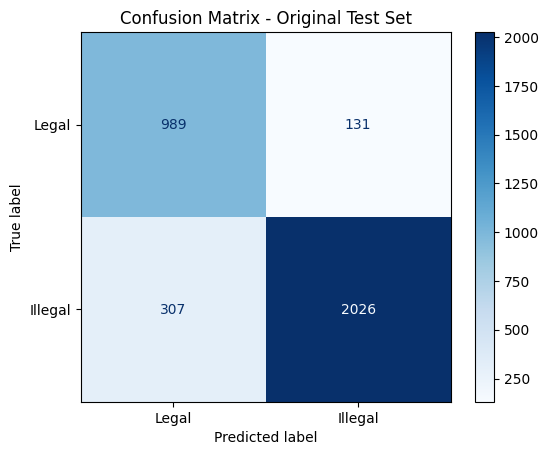


Balanced Test Set Results:
Accuracy: 0.8358
F1: 0.8461
Precision: 0.8919
Recall: 0.8049

Macierz pomyłek:
[[TN FP]
 [FN TP]]
[[1327  189]
 [ 378 1559]]


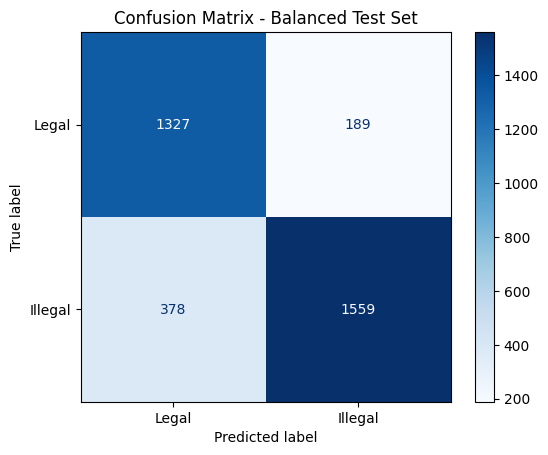

('./legal_classifier/tokenizer_config.json',
 './legal_classifier/special_tokens_map.json',
 './legal_classifier/vocab.json',
 './legal_classifier/merges.txt',
 './legal_classifier/added_tokens.json',
 './legal_classifier/tokenizer.json')

In [34]:
from datasets import load_dataset, DatasetDict, concatenate_datasets
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 1. Ładowanie danych bez żadnych modyfikacji
dataset = load_dataset("laugustyniak/abusive-clauses-pl")
original_dataset = DatasetDict({
    "train": dataset["train"],
    "val": dataset["validation"],
    "test": dataset["test"]
})

# 2. Tworzenie zbalansowanego test setu tylko do ewaluacji końcowej
combined = concatenate_datasets([original_dataset["val"], original_dataset["test"]])
combined_df = combined.to_pandas()

_, balanced_test_df = train_test_split(
    combined_df,
    test_size=len(original_dataset["test"]),
    stratify=combined_df["label"],
    random_state=42
)
balanced_test = Dataset.from_pandas(balanced_test_df)

# 3. Tokenizacja wszystkich zbiorów
model_name = "clarin-pl/roberta-polish-kgr10"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def preprocess_data(example):
    return tokenizer(
        example['text'],
        padding="max_length",
        truncation=True,
        max_length=128
    )

# Tokenizacja oryginalnych zbiorów
tokenized_original = original_dataset.map(preprocess_data, batched=True)
tokenized_original = tokenized_original.rename_column("label", "labels")
tokenized_original.set_format("torch")

# Tokenizacja zbalansowanego test setu
tokenized_balanced = balanced_test.map(preprocess_data, batched=True)
tokenized_balanced = tokenized_balanced.rename_column("label", "labels")
tokenized_balanced.set_format("torch")

# 4. Inicjalizacja modelu
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
).to(device)

# 5. Funkcja metryk
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average="binary", zero_division=0
    )
    acc = accuracy_score(labels, predictions)

    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall
    }

# 6. Konfiguracja treningu
training_args = TrainingArguments(
    output_dir="./results",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    save_total_limit=2,
    report_to="none"
)

# 7. Inicjalizacja Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_original["train"],
    eval_dataset=tokenized_original["val"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

# 8. Trening
trainer.train()

# 9. Ewaluacja końcowa na obu test setach
def print_results(name, dataset):
    results = trainer.evaluate(dataset)
    predictions = trainer.predict(dataset)

    # Obliczanie metryk
    cm = confusion_matrix(predictions.label_ids, np.argmax(predictions.predictions, axis=1))
    accuracy = accuracy_score(predictions.label_ids, np.argmax(predictions.predictions, axis=1))
    precision, recall, f1, _ = precision_recall_fscore_support(
        predictions.label_ids,
        np.argmax(predictions.predictions, axis=1),
        average="binary"
    )

    # Wyświetlanie wyników
    print(f"\n{'='*50}")
    print(f"{name} Results:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1: {f1:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")

    # Macierz pomyłek
    print("\nMacierz pomyłek:")
    print(f"[[TN FP]")
    print(f" [FN TP]]")
    print(np.array_str(cm, suppress_small=True))

    # Wizualizacja
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Legal", "Illegal"]
    )
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix - {name}")
    plt.show()
    plt.close()

print_results("Original Test Set", tokenized_original["test"])
print_results("Balanced Test Set", tokenized_balanced)

# 10. Wizualizacja wyników
def plot_confusion_matrix(dataset, name):
    predictions = trainer.predict(dataset)
    cm = confusion_matrix(predictions.label_ids, np.argmax(predictions.predictions, axis=1))
    ConfusionMatrixDisplay(cm, display_labels=["Legal", "Illegal"]).plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.savefig(f"confusion_matrix_{name.lower().replace(' ', '_')}.png")
    plt.close()

plot_confusion_matrix(tokenized_original["test"], "Original Test")
plot_confusion_matrix(tokenized_balanced, "Balanced Test")

# 11. Zapis modelu
model.save_pretrained("./legal_classifier")
tokenizer.save_pretrained("./legal_classifier")

In [ ]:
ZWYKLY BERT BEZ BALANCED SETOW

Using device: cuda


Map:   0%|          | 0/4284 [00:00<?, ? examples/s]

Map:   0%|          | 0/1519 [00:00<?, ? examples/s]

Map:   0%|          | 0/3453 [00:00<?, ? examples/s]

Map:   0%|          | 0/3453 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
<ipython-input-35-d8f9891834e7>:95: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.273100,0.661926,0.639236,0.450902,0.415129,0.493421
2,0.263400,0.655593,0.713627,0.406548,0.537906,0.326754
3,0.214300,0.826599,0.714286,0.495349,0.527228,0.467105



Original Test Set Results:
Accuracy: 0.8613
F1: 0.8937
Precision: 0.9268
Recall: 0.8628

Macierz pomyłek:
[[TN FP]
 [FN TP]]
[[ 961  159]
 [ 320 2013]]


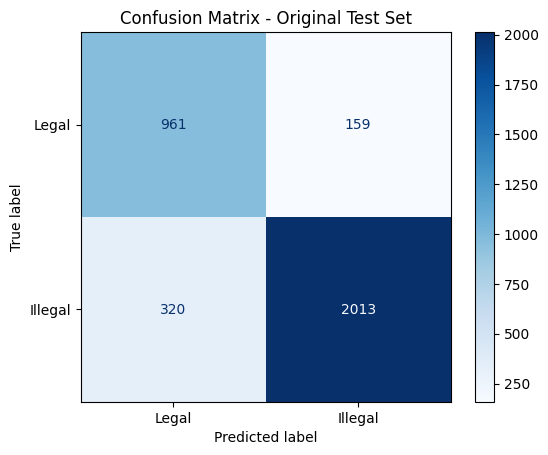


Balanced Test Set Results:
Accuracy: 0.8164
F1: 0.8311
Precision: 0.8586
Recall: 0.8054

Macierz pomyłek:
[[TN FP]
 [FN TP]]
[[1259  257]
 [ 377 1560]]


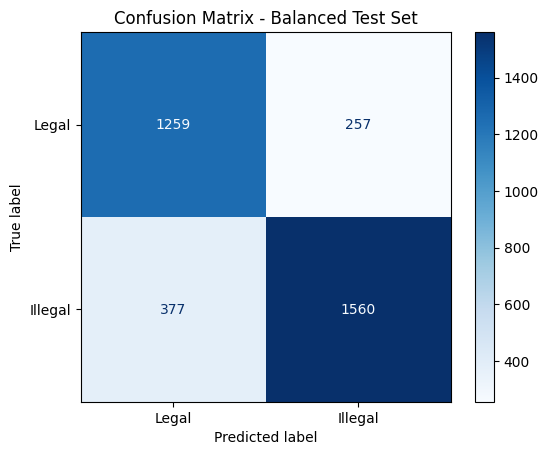

('./legal_classifier/tokenizer_config.json',
 './legal_classifier/special_tokens_map.json',
 './legal_classifier/vocab.txt',
 './legal_classifier/added_tokens.json',
 './legal_classifier/tokenizer.json')

In [35]:
from datasets import load_dataset, DatasetDict, concatenate_datasets
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 1. Ładowanie danych bez żadnych modyfikacji
dataset = load_dataset("laugustyniak/abusive-clauses-pl")
original_dataset = DatasetDict({
    "train": dataset["train"],
    "val": dataset["validation"],
    "test": dataset["test"]
})

# 2. Tworzenie zbalansowanego test setu tylko do ewaluacji końcowej
combined = concatenate_datasets([original_dataset["val"], original_dataset["test"]])
combined_df = combined.to_pandas()

_, balanced_test_df = train_test_split(
    combined_df,
    test_size=len(original_dataset["test"]),
    stratify=combined_df["label"],
    random_state=42
)
balanced_test = Dataset.from_pandas(balanced_test_df)

# 3. Tokenizacja wszystkich zbiorów
model_name = "bert-base-multilingual-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def preprocess_data(example):
    return tokenizer(
        example['text'],
        padding="max_length",
        truncation=True,
        max_length=128
    )

# Tokenizacja oryginalnych zbiorów
tokenized_original = original_dataset.map(preprocess_data, batched=True)
tokenized_original = tokenized_original.rename_column("label", "labels")
tokenized_original.set_format("torch")

# Tokenizacja zbalansowanego test setu
tokenized_balanced = balanced_test.map(preprocess_data, batched=True)
tokenized_balanced = tokenized_balanced.rename_column("label", "labels")
tokenized_balanced.set_format("torch")

# 4. Inicjalizacja modelu
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
).to(device)

# 5. Funkcja metryk
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average="binary", zero_division=0
    )
    acc = accuracy_score(labels, predictions)

    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall
    }

# 6. Konfiguracja treningu
training_args = TrainingArguments(
    output_dir="./results",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    save_total_limit=2,
    report_to="none"
)

# 7. Inicjalizacja Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_original["train"],
    eval_dataset=tokenized_original["val"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

# 8. Trening
trainer.train()

# 9. Ewaluacja końcowa na obu test setach
def print_results(name, dataset):
    results = trainer.evaluate(dataset)
    predictions = trainer.predict(dataset)

    # Obliczanie metryk
    cm = confusion_matrix(predictions.label_ids, np.argmax(predictions.predictions, axis=1))
    accuracy = accuracy_score(predictions.label_ids, np.argmax(predictions.predictions, axis=1))
    precision, recall, f1, _ = precision_recall_fscore_support(
        predictions.label_ids,
        np.argmax(predictions.predictions, axis=1),
        average="binary"
    )

    # Wyświetlanie wyników
    print(f"\n{'='*50}")
    print(f"{name} Results:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1: {f1:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")

    # Macierz pomyłek
    print("\nMacierz pomyłek:")
    print(f"[[TN FP]")
    print(f" [FN TP]]")
    print(np.array_str(cm, suppress_small=True))

    # Wizualizacja
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Legal", "Illegal"]
    )
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix - {name}")
    plt.show()
    plt.close()

print_results("Original Test Set", tokenized_original["test"])
print_results("Balanced Test Set", tokenized_balanced)

# 10. Wizualizacja wyników
def plot_confusion_matrix(dataset, name):
    predictions = trainer.predict(dataset)
    cm = confusion_matrix(predictions.label_ids, np.argmax(predictions.predictions, axis=1))
    ConfusionMatrixDisplay(cm, display_labels=["Legal", "Illegal"]).plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.savefig(f"confusion_matrix_{name.lower().replace(' ', '_')}.png")
    plt.close()

plot_confusion_matrix(tokenized_original["test"], "Original Test")
plot_confusion_matrix(tokenized_balanced, "Balanced Test")

# 11. Zapis modelu
model.save_pretrained("./legal_classifier")
tokenizer.save_pretrained("./legal_classifier")

In [ ]:
LEGAL BERT BEZ BALANCED SETOW

Using device: cuda


Map:   0%|          | 0/4284 [00:00<?, ? examples/s]

Map:   0%|          | 0/1519 [00:00<?, ? examples/s]

Map:   0%|          | 0/3453 [00:00<?, ? examples/s]

Map:   0%|          | 0/3453 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at nlpaueb/legal-bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
<ipython-input-36-2ae57ae7a0d8>:95: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.351100,0.728548,0.620803,0.304348,0.338710,0.276316
2,0.411700,0.697563,0.685978,0.149733,0.400000,0.092105
3,0.406600,0.656503,0.684661,0.243286,0.435028,0.168860



Original Test Set Results:
Accuracy: 0.8147
F1: 0.8588
Precision: 0.8849
Recall: 0.8341

Macierz pomyłek:
[[TN FP]
 [FN TP]]
[[ 867  253]
 [ 387 1946]]


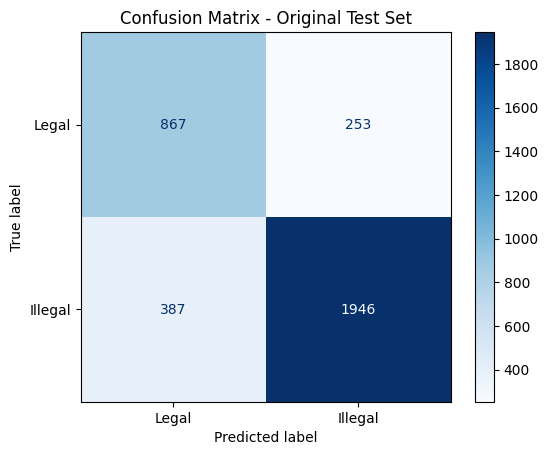


Balanced Test Set Results:
Accuracy: 0.7651
F1: 0.7834
Precision: 0.8114
Recall: 0.7574

Macierz pomyłek:
[[TN FP]
 [FN TP]]
[[1175  341]
 [ 470 1467]]


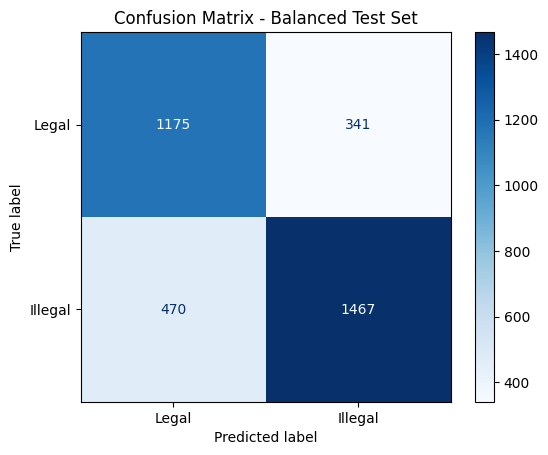

('./legal_classifier/tokenizer_config.json',
 './legal_classifier/special_tokens_map.json',
 './legal_classifier/vocab.txt',
 './legal_classifier/added_tokens.json',
 './legal_classifier/tokenizer.json')

In [36]:
from datasets import load_dataset, DatasetDict, concatenate_datasets
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 1. Ładowanie danych bez żadnych modyfikacji
dataset = load_dataset("laugustyniak/abusive-clauses-pl")
original_dataset = DatasetDict({
    "train": dataset["train"],
    "val": dataset["validation"],
    "test": dataset["test"]
})

# 2. Tworzenie zbalansowanego test setu tylko do ewaluacji końcowej
combined = concatenate_datasets([original_dataset["val"], original_dataset["test"]])
combined_df = combined.to_pandas()

_, balanced_test_df = train_test_split(
    combined_df,
    test_size=len(original_dataset["test"]),
    stratify=combined_df["label"],
    random_state=42
)
balanced_test = Dataset.from_pandas(balanced_test_df)

# 3. Tokenizacja wszystkich zbiorów
model_name = "nlpaueb/legal-bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def preprocess_data(example):
    return tokenizer(
        example['text'],
        padding="max_length",
        truncation=True,
        max_length=128
    )

# Tokenizacja oryginalnych zbiorów
tokenized_original = original_dataset.map(preprocess_data, batched=True)
tokenized_original = tokenized_original.rename_column("label", "labels")
tokenized_original.set_format("torch")

# Tokenizacja zbalansowanego test setu
tokenized_balanced = balanced_test.map(preprocess_data, batched=True)
tokenized_balanced = tokenized_balanced.rename_column("label", "labels")
tokenized_balanced.set_format("torch")

# 4. Inicjalizacja modelu
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
).to(device)

# 5. Funkcja metryk
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average="binary", zero_division=0
    )
    acc = accuracy_score(labels, predictions)

    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall
    }

# 6. Konfiguracja treningu
training_args = TrainingArguments(
    output_dir="./results",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    save_total_limit=2,
    report_to="none"
)

# 7. Inicjalizacja Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_original["train"],
    eval_dataset=tokenized_original["val"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

# 8. Trening
trainer.train()

# 9. Ewaluacja końcowa na obu test setach
def print_results(name, dataset):
    results = trainer.evaluate(dataset)
    predictions = trainer.predict(dataset)

    # Obliczanie metryk
    cm = confusion_matrix(predictions.label_ids, np.argmax(predictions.predictions, axis=1))
    accuracy = accuracy_score(predictions.label_ids, np.argmax(predictions.predictions, axis=1))
    precision, recall, f1, _ = precision_recall_fscore_support(
        predictions.label_ids,
        np.argmax(predictions.predictions, axis=1),
        average="binary"
    )

    # Wyświetlanie wyników
    print(f"\n{'='*50}")
    print(f"{name} Results:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1: {f1:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")

    # Macierz pomyłek
    print("\nMacierz pomyłek:")
    print(f"[[TN FP]")
    print(f" [FN TP]]")
    print(np.array_str(cm, suppress_small=True))

    # Wizualizacja
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Legal", "Illegal"]
    )
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix - {name}")
    plt.show()
    plt.close()

print_results("Original Test Set", tokenized_original["test"])
print_results("Balanced Test Set", tokenized_balanced)

# 10. Wizualizacja wyników
def plot_confusion_matrix(dataset, name):
    predictions = trainer.predict(dataset)
    cm = confusion_matrix(predictions.label_ids, np.argmax(predictions.predictions, axis=1))
    ConfusionMatrixDisplay(cm, display_labels=["Legal", "Illegal"]).plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.savefig(f"confusion_matrix_{name.lower().replace(' ', '_')}.png")
    plt.close()

plot_confusion_matrix(tokenized_original["test"], "Original Test")
plot_confusion_matrix(tokenized_balanced, "Balanced Test")

# 11. Zapis modelu
model.save_pretrained("./legal_classifier")
tokenizer.save_pretrained("./legal_classifier")